In [139]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [140]:
data = pd.read_csv('raw_data/heart.csv')

In [141]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [142]:
data.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
131,46,M,ASY,110,202,0,Normal,150,Y,0.0,Flat,1
15,54,F,ATA,120,273,0,Normal,150,N,1.5,Flat,0
254,55,M,ASY,145,248,0,Normal,96,Y,2.0,Flat,1
170,29,M,ATA,120,243,0,Normal,160,N,0.0,Up,0
83,52,M,ATA,160,196,0,Normal,165,N,0.0,Up,0
589,74,M,NAP,140,237,1,Normal,94,N,0.0,Flat,1
799,53,M,NAP,130,246,1,LVH,173,N,0.0,Up,0
595,60,M,ASY,130,186,1,LVH,140,Y,0.5,Flat,1
70,57,M,ATA,140,265,0,ST,145,Y,1.0,Flat,1
251,48,M,ASY,120,260,0,Normal,115,N,2.0,Flat,1


In [143]:
data.shape

(918, 12)

In [144]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [145]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [146]:
data.corr(numeric_only=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.254399,-0.095282,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.254399,1.000000,0.100893,0.070193,-0.112135,0.164803,0.107589
Cholesterol,-0.095282,0.100893,1.000000,-0.260974,0.235792,0.050148,-0.232741
FastingBS,0.198039,0.070193,-0.260974,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.112135,0.235792,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.164803,0.050148,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.107589,-0.232741,0.267291,-0.400421,0.403951,1.000000


In [147]:
columns = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease']
num_column = data.select_dtypes(include=np.number).columns
cat_column = data.select_dtypes(include="str").columns
for col in columns:
    print(col , " = " ,data[col].nunique())

Age  =  50
Sex  =  2
ChestPainType  =  4
RestingBP  =  67
Cholesterol  =  222
FastingBS  =  2
RestingECG  =  3
MaxHR  =  119
ExerciseAngina  =  2
Oldpeak  =  53
ST_Slope  =  3
HeartDisease  =  2


In [148]:
print(cat_column)
print(num_column)
data.info()

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [149]:
data['Sex'] = data['Sex'].map({'M':0,'F':1},astype = int)


In [150]:
data.sample(10)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
723,59,0,ASY,140,177,0,Normal,162,Y,0.0,Up,1
392,61,0,ASY,130,0,0,LVH,115,N,0.0,Flat,1
900,58,0,ASY,114,318,0,ST,140,N,4.4,Down,1
909,63,1,ASY,124,197,0,Normal,136,Y,0.0,Flat,1
804,70,0,NAP,160,269,0,Normal,112,Y,2.9,Flat,1
117,59,1,ASY,130,338,1,ST,130,Y,1.5,Flat,1
662,44,0,ASY,110,197,0,LVH,177,N,0.0,Up,1
174,52,0,ASY,140,266,0,Normal,134,Y,2.0,Flat,1
603,74,0,ASY,155,310,0,Normal,112,Y,1.5,Down,1
634,40,0,TA,140,199,0,Normal,178,Y,1.4,Up,0


In [151]:
data['ExerciseAngina'] = data['ExerciseAngina'].map({'Y':1,'N':0},dtype=int)

In [152]:
data.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
85,66,0,ASY,140,139,0,Normal,94,1,1.0,Flat,1
464,59,0,NAP,131,0,0,Normal,128,1,2.0,Down,1
120,47,1,NAP,135,248,1,Normal,170,0,0.0,Flat,1
185,58,0,NAP,160,211,1,ST,92,0,0.0,Flat,1
171,40,0,NAP,140,235,0,Normal,188,0,0.0,Up,0
90,49,1,ATA,110,208,0,Normal,160,0,0.0,Up,0
753,34,1,ATA,118,210,0,Normal,192,0,0.7,Up,0
151,48,0,ATA,100,159,0,Normal,100,0,0.0,Up,0
898,35,0,ATA,122,192,0,Normal,174,0,0.0,Up,0
195,62,1,TA,160,193,0,Normal,116,0,0.0,Up,0


In [153]:
data['ST_Slope'] = data['ST_Slope'].map({'Up':0,'Flat':1,'Down':2},dtype=int)

In [154]:
data.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
610,54,1,ASY,127,333,1,ST,154,0,0.0,1,1
685,61,0,ASY,120,260,0,Normal,140,1,3.6,1,1
4,54,0,NAP,150,195,0,Normal,122,0,0.0,0,0
609,46,0,ASY,134,310,0,Normal,126,0,0.0,1,1
697,58,0,ASY,150,270,0,LVH,111,1,0.8,0,1
498,67,0,ASY,160,384,1,ST,130,1,0.0,1,1
624,63,1,ASY,150,407,0,LVH,154,0,4.0,1,1
150,39,0,ATA,130,215,0,Normal,120,0,0.0,0,0
201,46,0,NAP,120,230,0,Normal,150,0,0.0,0,0
870,71,1,ATA,160,302,0,Normal,162,0,0.4,0,0


In [155]:
data = pd.get_dummies(data=data,columns=['ChestPainType','RestingECG'],drop_first=True,dtype=int)
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,0,140,289,0,172,0,0.0,0,0,1,0,0,1,0
1,49,1,160,180,0,156,0,1.0,1,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0.0,0,0,1,0,0,0,1
3,48,1,138,214,0,108,1,1.5,1,1,0,0,0,1,0
4,54,0,150,195,0,122,0,0.0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,1,1,0,0,1,1,0
914,68,0,144,193,1,141,0,3.4,1,1,0,0,0,1,0
915,57,0,130,131,0,115,1,1.2,1,1,0,0,0,1,0
916,57,1,130,236,0,174,0,0.0,1,1,1,0,0,0,0


In [156]:
data.shape

(918, 15)

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn. linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn. tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [160]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,0,140,289,0,172,0,0.0,0,0,1,0,0,1,0
1,49,1,160,180,0,156,0,1.0,1,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0.0,0,0,1,0,0,0,1
3,48,1,138,214,0,108,1,1.5,1,1,0,0,0,1,0
4,54,0,150,195,0,122,0,0.0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,1,1,0,0,1,1,0
914,68,0,144,193,1,141,0,3.4,1,1,0,0,0,1,0
915,57,0,130,131,0,115,1,1.2,1,1,0,0,0,1,0
916,57,1,130,236,0,174,0,0.0,1,1,1,0,0,0,0


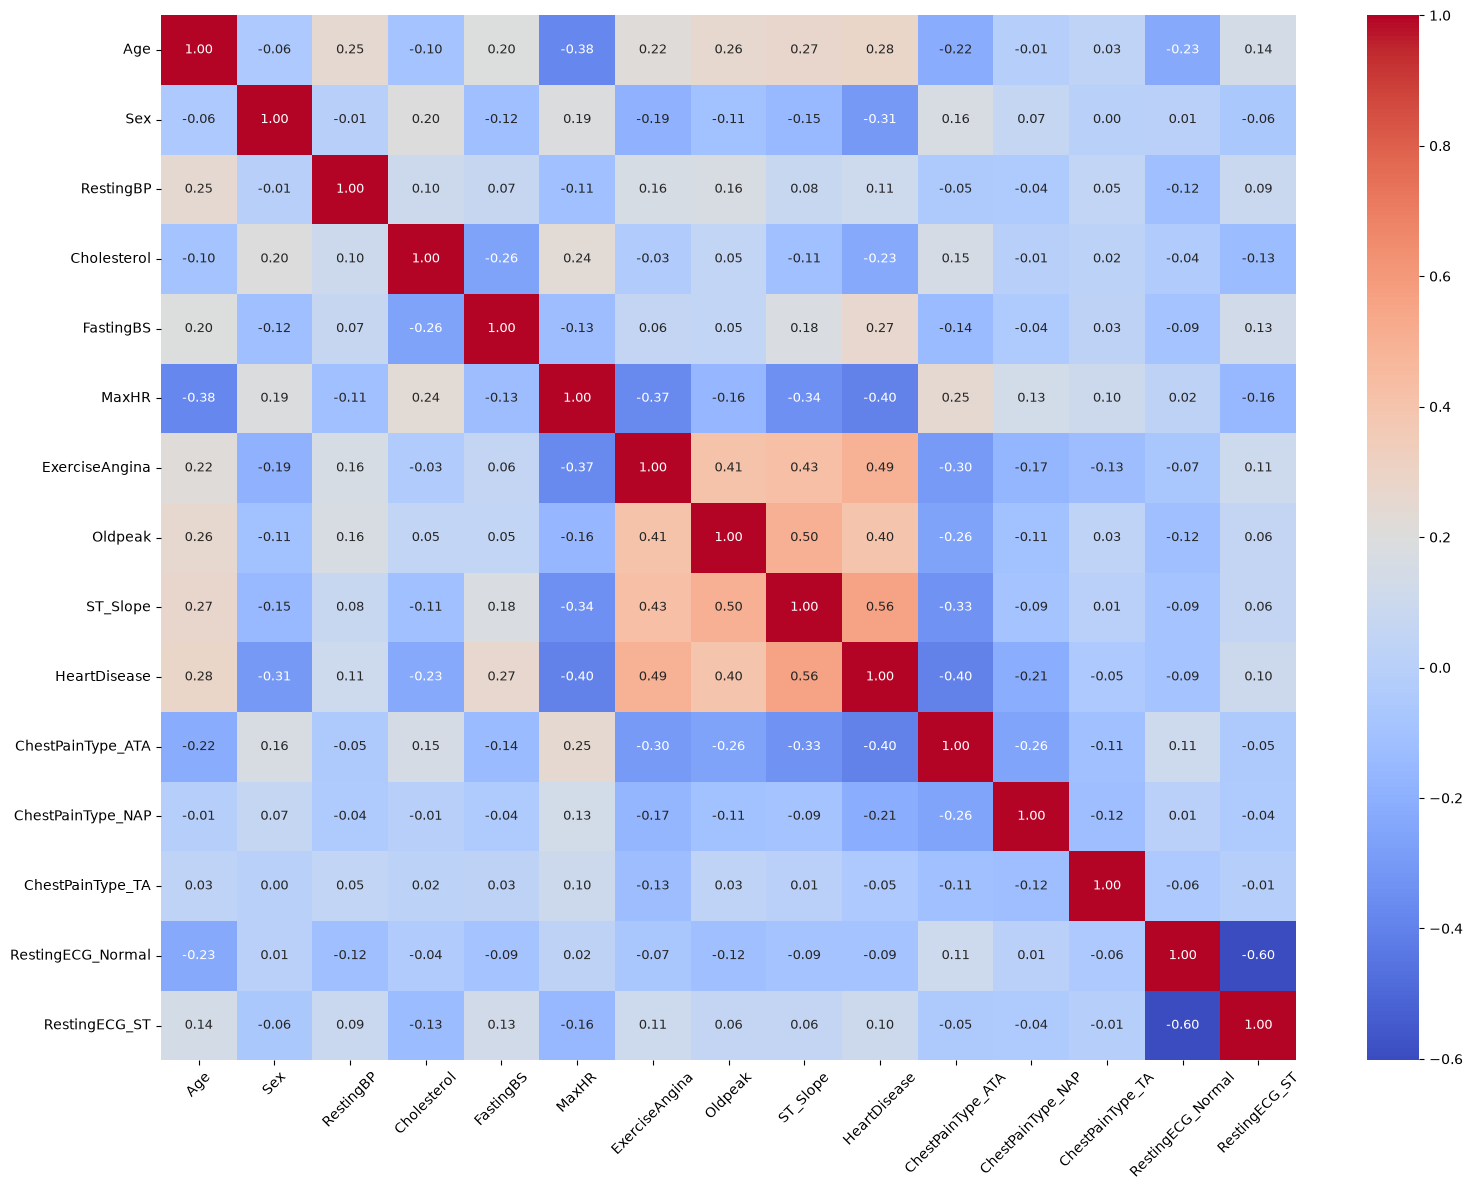

In [164]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 9}
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [169]:
data.columns
data.shape

(918, 15)

In [166]:
remove_col = ['ChestPainType_TA','RestingECG_Normal', 'RestingECG_ST', 'HeartDisease']
X_encoded = data.drop(columns=remove_col)

In [170]:
y = data['HeartDisease']
X_encoded.shape

(918, 11)

In [171]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn. linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn. tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [176]:
# models = {
#     'Logistic Regression' : LogisticRegression(),
#     'GaussianNB':GaussianNB(),
#     'Decision Tree Classifier' : DecisionTreeClassifier(),
#     'SVM': SVC(),
#     'KNN':KNeighborsClassifier()
# }

In [172]:
X_train,X_test,y_train,y_test  = train_test_split(
    X_encoded,y,test_size=0.20,random_state=42
)

In [174]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [175]:
X_train_scaled

array([[-1.24506731, -0.54060477, -0.70898547, ...,  2.25746543,
        -0.48333575,  1.87905939],
       [-1.8862362 , -0.54060477, -0.16628515, ..., -1.07985506,
        -0.48333575,  1.87905939],
       [ 0.25099346, -0.54060477,  0.91911549, ...,  0.58880518,
        -0.48333575, -0.53218116],
       ...,
       [ 0.67843939, -0.54060477, -0.16628515, ..., -1.07985506,
        -0.48333575, -0.53218116],
       [ 0.67843939, -0.54060477,  1.02765555, ..., -1.07985506,
        -0.48333575, -0.53218116],
       [-1.45879027,  1.84978019,  0.91911549, ...,  0.58880518,
        -0.48333575, -0.53218116]], shape=(734, 11))

In [177]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'GaussianNB':GaussianNB(),
    'Decision Tree Classifier' : DecisionTreeClassifier(),
    'SVM': SVC(),
    'KNN':KNeighborsClassifier()
}

In [179]:
result = []
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    result.append({
        'model':name,
        'Accuracy':round(acc,4),
        "f1 score":round(f1,4)
        }
    )

In [180]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.8424, 'f1 score': 0.8626},
 {'model': 'GaussianNB', 'Accuracy': 0.837, 'f1 score': 0.8571},
 {'model': 'Decision Tree Classifier', 'Accuracy': 0.8533, 'f1 score': 0.8778},
 {'model': 'SVM', 'Accuracy': 0.8587, 'f1 score': 0.8774},
 {'model': 'KNN', 'Accuracy': 0.8533, 'f1 score': 0.872}]

In [183]:
import joblib
joblib.dump(models['KNN'],'KNN_heart.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X_encoded.columns,'columns.pkl')


['columns.pkl']